In [1]:
%matplotlib widget
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from scipy.stats import uniform
from scipy.optimize import curve_fit
import os
from netCDF4 import Dataset
from uvspec_my_functions import fernald_new1, fernald_new2, alphabeta, rte_lidar, fernald_new1_mc, fernald_new2_mc
from multiprocessing import Pool
import netCDF4 as nc
plt.rcParams.update({'font.size': 13})

In [2]:
PATH_FIG = '../figures/'
PATH_LUCIANA = '../luciana_exemplo/'
PATH_SIZDIST = '../aerosol/sizedist/'
PATH_OUT_MIE = '../mie_output/'
PATH_REFRAC_FILE = '../refrac_files/'

## Defining some functions

In [3]:
def lognormal_monomodal_nr(r, a1, mu1, s1):
    return a1/(np.sqrt(2*np.pi)*r*np.log(s1))*np.exp(-.5*((np.log(r)-np.log(mu1))/np.log(s1))**2)

def lognormal_monomodal_nlnr(r, a1, mu1, s1):
    return a1/(np.sqrt(2*np.pi)*np.log(s1))*np.exp(-.5*((np.log(r)-np.log(mu1))/np.log(s1))**2)

def volume_lognormal_monomodal_nlnr(r, a1, mu1, s1):
    return a1*(4/3*np.pi*r**3)/(np.sqrt(2*np.pi)*np.log(s1))*np.exp(-.5*((np.log(r)-np.log(mu1))/np.log(s1))**2)

def volume_lognorm_bimodal_nlnr(r, a1, a2, mu1, mu2, s1, s2):
    return (4/3*np.pi*r**3)*(a1/(np.sqrt(2*np.pi)*np.log(s1))*np.exp(-.5*((np.log(r)-np.log(mu1))/np.log(s1))**2) + a2/(np.sqrt(2*np.pi)*np.log(s2))*np.exp(-.5*((np.log(r)-np.log(mu2))/np.log(s2))**2))

def lognorm_bimodal_nlnr(r, a1, a2, mu1, mu2, s1, s2):
    return a1/(np.sqrt(2*np.pi)*np.log(s1))*np.exp(-.5*((np.log(r)-np.log(mu1))/np.log(s1))**2) + a2/(np.sqrt(2*np.pi)*np.log(s2))*np.exp(-.5*((np.log(r)-np.log(mu2))/np.log(s2))**2)

def run_mie_sizedist(mie_input, input_filename, verbose_filename):
    
    # ------- Write --------
    with open(input_filename, 'w') as f:
        for key in mie_input:
            print(key, mie_input[key], file=f)
            
    # ------- RUN --------
    COMAND = '(mie <' + input_filename +'> mie.out)> '+verbose_filename+' 2>&1'
    os.system(COMAND)

def abs_scat_converges(scat_m, abs_m, re, im, delta_re, delta_im, epsilon, sizdist_path, sizdist_filename, outputmie_path, wavelenght):

    dir_list_sizdist = os.listdir(sizdist_path)
    rho = 1 # g/cm^3
    # exemplo sizedistfilename:
    # szdist = '20140715180000_SIZEDIST.DAT'
    mie_inputs_2 = []
    mie_outputs_2 = []
    input_filenames_2 = []
    verb_filename_2 = []
    outp_filename_2 = []
    dic_output = {}
    delta_w = abs(wavelenght[0] - wavelenght[1])
    
    error_qscat = 999
    error_qabs = 999
    results = []
    i_f = 0
    while abs(error_qabs) > epsilon or abs(error_qscat) > epsilon:
        # criating the dictionary that will be used to write the input file:
        input_filenames_2.append(sizdist_filename[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'.inp')
        verb_filename_2.append(sizdist_filename[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_verb.txt')
        outp_filename_2.append(sizdist_filename[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_')
        mie_inputs_2.append({'mie_program': 'MIEV0',
                                 'refrac user': str(re) + ' ' + str(im),  
                                 'size_distribution_file':sizdist_path+sizdist_filename,
                                 'wavelength': str(wavelenght[0]) + ' ' + str(wavelenght[1]),
                                 'wavelength_step':delta_w,  
                                 'nstokes':4,
                                 'nmom':2000,
                                 'dx_max':0.0003 ,
                                 'n_r_max':20 ,
                                 'output_user':'netcdf',
                                 'basename':outputmie_path+outp_filename_2[i_f], 
                                 'verbose':''})

        # run the mie code:
        run_mie_sizedist(mie_inputs_2[i_f],
                             './mie_inputs_2/'+input_filenames_2[i_f],
                             './mie_inputs_2/'+verb_filename_2[i_f])
        #print('rodou mie')
        #print(outputmie_path+outp_filename_2[i_f])
            # read mie output:
        ree = nc.Dataset(outputmie_path+outp_filename_2[i_f]+'mie.cdf').variables['refre'][:]
        imm = nc.Dataset(outputmie_path+outp_filename_2[i_f]+'mie.cdf').variables['refim'][:]
        ext = nc.Dataset(outputmie_path+outp_filename_2[i_f]+'mie.cdf').variables['ext'][:] # km^-1/(g/m^3)
        ssa = nc.Dataset(outputmie_path+outp_filename_2[i_f]+'mie.cdf').variables['ssa'][:]
        sizdist = np.loadtxt(sizdist_path+sizdist_filename) # 2 column: (micro m)^-1 cm^-3
        n_m = (rho/1e6)*4/3*np.pi*sizdist[:,0]**3*sizdist[:,1] # mircro g/(micro m^3) x (micro m)^2 cm^-3 
                                                                        # = mircro g micro m^-1 cm^-3 
        mass = integrate.simps(n_m, sizdist[:,0]) # mircro g cm^-3 == g/m^3
        qext = ext*1e3*mass
        qscat = ssa*qext
        qabs = (1-ssa)*qext
        results.append([ree[0], imm[0], qscat[0][0], qabs[1][0], mass])

        fabs = abs_m/qabs[1][0]
        fscat = scat_m/qscat[0][0]
        error_qabs = 1-fabs
        error_qscat = 1-fscat
        print("Re = %.5f Im = %.4f qabs_err = %.3f qscat_err = %.2f Abs = %.2f, Scat = %.2f"%(re, im, error_qabs, error_qscat, qabs[1][0], qscat[0][0]))
        i_f+=1
        if error_qabs < -epsilon:
            im += delta_im
        elif error_qabs > epsilon:
            im -= delta_im
        elif error_qscat < -epsilon:
            re += delta_re
        else:
            re -= delta_re/2
    os.system('rm ./mie_inputs_2/*')
    os.system('rm ../mie_out_2/*')
    return np.array(results, float)

## Reading size distribution file and plotting

In [3]:
data= pd.read_csv(PATH_LUCIANA+'input_sizedist_exemplo.txt', skiprows=1, sep='\t', header=None).T
time_string = list(map(str, np.int_(data.iloc[0,1:]))) # get time in the first colum of .csv and convert to string
time_serie = pd.to_datetime(time_string)
size_dist = data.iloc[1:,:].to_numpy() # 1 column: diameter [nm], 2 to end column: number concentration dN/dlog10(r) [#/cm^3]

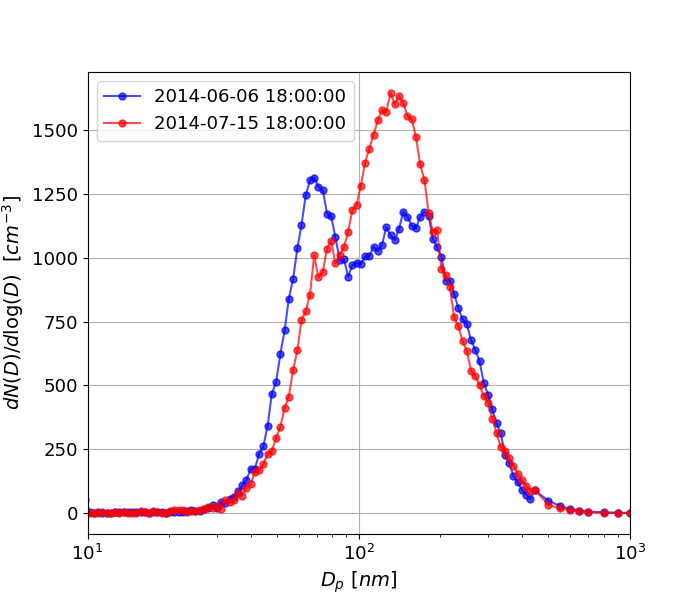

In [5]:
fig = plt.figure(figsize=[7,6])

ax1 = plt.subplot()
plot_siz_1 = ax1.plot(size_dist[:,0], size_dist[:,1], color='blue', marker='o', markersize=5., alpha=0.7, label = str(time_serie[0]))
plot_siz_2 = ax1.plot(size_dist[:,0], size_dist[:,2], color='red', marker='o', markersize=5., alpha=0.7, label = str(time_serie[1]))

#ttl = ax1.set_title(str(time_serie[0]))
#ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
xlabx.set_style('italic')
xlabx.set_size(14)
xlaby.set_style('italic')
xlaby.set_size(14)
ax1.set_xlabel(r'$D_{p}\ [nm]$')
ax1.set_ylabel(r'$dN(D)/d \log(D)\ \ [cm^{-3}]$')
ax1.grid()
ax1.legend()
ax1.set_xlim([1e1, 1e3])
#ax1.set_ylim([0, 2000])
ax1.set_xscale('log')
plt.savefig(PATH_FIG+"size_distributions_example.png", dpi=400)
plt.show()

## Convert size distribution data to libRadtran format and save it

In [7]:
radius = size_dist[:,0]*1e-3/2 # radius in micrometers

for i, time in enumerate(time_string):
    size_dist_dndr = size_dist[:,i+1]/(np.log(10)*radius) # number concentration in micrometers^-1 cm^-3
    aux = np.concatenate((radius.reshape(radius.shape[0],1), size_dist_dndr.reshape(size_dist_dndr.shape[0],1)), axis=1)

    np.savetxt(PATH_SIZDIST+time+'_SIZEDIST.DAT',
               aux, 
               delimiter=' ', 
               header='R [micro] \t n(R) [(micro m)^-1 cm^-3]')

## Here we define waveleghts and the refractive index grid for the mie calculations

In [27]:
wavelen = np.array([450, 637], float)
# defining refractive indexes grid:
real_min, real_max = 1.33, 2.0
im_min, im_max = 1e-10, 0.1
delta_real, delta_im = 0.01, 0.001

refrac_real = np.around(np.arange(real_min, real_max, delta_real), 2) # do not take the stop value, only in some cases 
refrac_im = np.around(np.arange(im_min, im_max, delta_im), 4) # do not take the stop value, only in some cases
nx = refrac_real.shape[0]
ny = refrac_im.shape[0]

realv, imv = np.meshgrid(refrac_real, refrac_im)
print('Real refractive index grid:\n')
print(realv)
print('\nImaginary refractive index grid:\n')
print(imv)

Real refractive index grid:

[[1.33 1.34 1.35 ... 1.97 1.98 1.99]
 [1.33 1.34 1.35 ... 1.97 1.98 1.99]
 [1.33 1.34 1.35 ... 1.97 1.98 1.99]
 ...
 [1.33 1.34 1.35 ... 1.97 1.98 1.99]
 [1.33 1.34 1.35 ... 1.97 1.98 1.99]
 [1.33 1.34 1.35 ... 1.97 1.98 1.99]]

Imaginary refractive index grid:

[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.001 0.001 0.001 ... 0.001 0.001 0.001]
 [0.002 0.002 0.002 ... 0.002 0.002 0.002]
 ...
 [0.097 0.097 0.097 ... 0.097 0.097 0.097]
 [0.098 0.098 0.098 ... 0.098 0.098 0.098]
 [0.099 0.099 0.099 ... 0.099 0.099 0.099]]


## Define input and run the scattering mie code just for a fisrt test 

In [20]:
# create the input file for the mie executable:
mie_input = {'mie_program': 'MIEV0',
               'refrac user': str(real_min) + ' ' + str(im_min), 
               'size_distribution_file':PATH_SIZDIST+'20140606180000_SIZEDIST.DAT', 
               'wavelength': '450 637',
               'wavelength_step':187, 
               'nstokes':4,
               'nmom':2000,
               'dx_max':0.0003 ,
               'n_r_max':20 ,
               'output_user':'netcdf',
               'basename':'./test_', 
               'verbose':''}

# just run for a first test:
run_mie_sizedist(mie_input,
                 './mie_inputs/test.inp',
                 'verbose.txt') 

## Save a file with the following collumns : wavelenght, real, imaginary 

In [28]:
for wl in wavelen:
    refrac_file = []
    for i in range(nx):
        for j in range(ny):
            refrac_file.append([wl, realv[j,i], imv[j,i]])       
    np.savetxt(PATH_REFRAC_FILE+'refrac_index_'+str(wl)+'.txt', refrac_file, delimiter=' ', header='wavelengh [nm] \t real \t imaginary')

## Create input arguments to mie function

In [29]:
# reading refracive index filenames for each wavelengh:
dir_list_refrac = os.listdir(PATH_REFRAC_FILE)
dir_list_sizdist = os.listdir(PATH_SIZDIST)
n_dir_refrac = len(dir_list_refrac)
# criate mie input files and save the input filename for each wavelengh:
mie_inputs = []
input_filenames = []
verb_filename = []
for szdist in dir_list_sizdist:
    for refrac in dir_list_refrac:
        input_filenames.append(szdist[:-4]+'_'+refrac[:-4]+'.inp')
        verb_filename.append(szdist[:-4]+'_'+refrac[:-4]+'_verb.txt')
        mie_inputs.append({'mie_program': 'MIEV0',
                   'refrac file':PATH_REFRAC_FILE+refrac, 
                   'size_distribution_file':PATH_SIZDIST+szdist, 
                   'nstokes':4,
                   'nmom':2000,
                   'dx_max':0.0003 ,
                   'n_r_max':20 ,
                   'output_user':'netcdf',
                   'basename':PATH_OUT_MIE+szdist[:-4]+'_'+refrac[:-4]+'_', 
                   'verbose':''})

## Run mie function in paralel for each wavelenght

In [30]:
with Pool() as pool:
    # call the same function with different data in parallel
    itens = [(mie_inputs[i], './mie_inputs/'+input_filenames[i], './mie_inputs/'+verb_filename[i]) for i in range(len(input_filenames))]
    pool.starmap(run_mie_sizedist, itens)

## Reading mie output filename

In [7]:
dir_list_mie = os.listdir(PATH_OUT_MIE)
n_dir_mie = len(dir_list_mie)
print('Mie output filenames:\n')
for file in dir_list_mie:
    print(file)

Mie output filenames:

20140715180000_SIZEDIST_refrac_index_637.0_mie.cdf
20140606180000_SIZEDIST_refrac_index_637.0_mie.cdf
20140715180000_SIZEDIST_refrac_index_450.0_mie.cdf
20140606180000_SIZEDIST_refrac_index_450.0_mie.cdf


### Read an example of mie output (netcdf format) and print:

In [124]:
print(nc.Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['refre'])
print('\n')
print(nc.Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['ext'])
print('\n')
print(nc.Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['ssa'])
print('\n')
print(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['wavelen'][:])
print('\n')
print(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['refre'][:])
print('\n')
print(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['refim'][:])
print('\n')
print(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['ext'][:])
print('\n')
print(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['ssa'][:])

<class 'netCDF4._netCDF4.Variable'>
float64 refre(nlam)
    long_name: refractive index (real)
    units:  
unlimited dimensions: 
current shape = (30,)
filling on, default _FillValue of 9.969209968386869e+36 used


<class 'netCDF4._netCDF4.Variable'>
float64 ext(nlam, nreff)
    long_name: extinction coefficient
    units: km^-1/(g/m^3)
unlimited dimensions: 
current shape = (30, 1)
filling on, default _FillValue of 9.969209968386869e+36 used


<class 'netCDF4._netCDF4.Variable'>
float64 ssa(nlam, nreff)
    long_name: single scattering albedo
    units: -
unlimited dimensions: 
current shape = (30, 1)
filling on, default _FillValue of 9.969209968386869e+36 used


[0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45
 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45 0.45
 0.45 0.45]


[1.34000003 1.34000003 1.34000003 1.40999997 1.40999997 1.40999997
 1.48000002 1.48000002 1.48000002 1.54999995 1.54999995 1.54999995
 1.62       1.62       1.62       1.

In [125]:
refre = np.around(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['refre'][:], 2)
refim = np.around(Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['refim'][:], 4)
ext = Dataset(PATH_OUT_MIE+dir_list_mie[2]).variables['ext'][:]
for i in range(refre.shape[0]):
    print(refre[i], refim[i], ext[i])
    
xx = refre.reshape(nx, ny).T
yy = refim.reshape(nx, ny).T
zz = ext.reshape(nx, ny).T
print(xx)
print(yy)
print(zz)

1.34 0.0 [4073.34938332]
1.34 0.07 [5311.34594113]
1.34 0.14 [6415.1445243]
1.41 0.0 [5658.43233654]
1.41 0.07 [6614.5820087]
1.41 0.14 [7501.5042295]
1.48 0.0 [7304.82004673]
1.48 0.07 [7989.54626432]
1.48 0.14 [8655.76037408]
1.55 0.0 [8964.39979209]
1.55 0.07 [9382.42956387]
1.55 0.14 [9836.20872426]
1.62 0.0 [10527.86773216]
1.62 0.07 [10747.72421703]
1.62 0.14 [11007.07142594]
1.69 0.0 [12093.82122476]
1.69 0.07 [12060.64574641]
1.69 0.14 [12139.11967263]
1.76 0.0 [13441.26051103]
1.76 0.07 [13280.5680221]
1.76 0.14 [13206.92998224]
1.83 0.0 [14741.59714434]
1.83 0.07 [14400.19885972]
1.83 0.14 [14191.91824826]
1.9 0.0 [15870.82583987]
1.9 0.07 [15387.36394942]
1.9 0.14 [15078.3148359]
1.97 0.0 [16660.71095062]
1.97 0.07 [16230.68486889]
1.97 0.14 [15860.93577137]
[[1.34 1.41 1.48 1.55 1.62 1.69 1.76 1.83 1.9  1.97]
 [1.34 1.41 1.48 1.55 1.62 1.69 1.76 1.83 1.9  1.97]
 [1.34 1.41 1.48 1.55 1.62 1.69 1.76 1.83 1.9  1.97]]
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.07 

## Print extinction normalized by the mass size distribution (raw mie output):

In [31]:
rho = 1 # g/cm^3
dic_mie_output = {}
for file in os.listdir(PATH_OUT_MIE):
    ree = nc.Dataset(PATH_OUT_MIE+file).variables['refre'][:].reshape(nx, ny).T
    imm = nc.Dataset(PATH_OUT_MIE+file).variables['refim'][:].reshape(nx, ny).T
    extt = nc.Dataset(PATH_OUT_MIE+file).variables['ext'][:].reshape(nx, ny).T # km^-1/(g/m^3)
    ssaa = nc.Dataset(PATH_OUT_MIE+file).variables['ssa'][:].reshape(nx, ny).T
    sizdist = np.loadtxt(PATH_SIZDIST+file[:23]+'.DAT') # 2 column: (micro m)^-1 cm^-3
    n_m = (rho/1e6)*4/3*np.pi*sizdist[:,0]**3*sizdist[:,1] # mircro g/(micro m^3) x (micro m)^2 cm^-3 
                                                            # = mircro g micro m^-1 cm^-3 
    mass = integrate.simps(n_m, sizdist[:,0]) # mircro g cm^-3 == g/m^3
    qext = extt*1e3*mass
    qscat = ssaa*qext
    qabs = (1-ssaa)*qext
    dic_mie_output[file] = [ree, imm, qext, qscat, qabs, ssaa, sizdist, n_m]
    # units { [a.u], [a.u], [Mm^-1], [Mm^-1], [Mm^-1], [a.u], [(micro m)^-1 cm^-3], [mircro g micro m^-1 cm^-3] }

print('Output mie dictionary keys:\n')
for key in dic_mie_output:
    print(key)

Output mie dictionary keys:

20140715180000_SIZEDIST_refrac_index_637.0_mie.cdf
20140606180000_SIZEDIST_refrac_index_637.0_mie.cdf
20140715180000_SIZEDIST_refrac_index_450.0_mie.cdf
20140606180000_SIZEDIST_refrac_index_450.0_mie.cdf


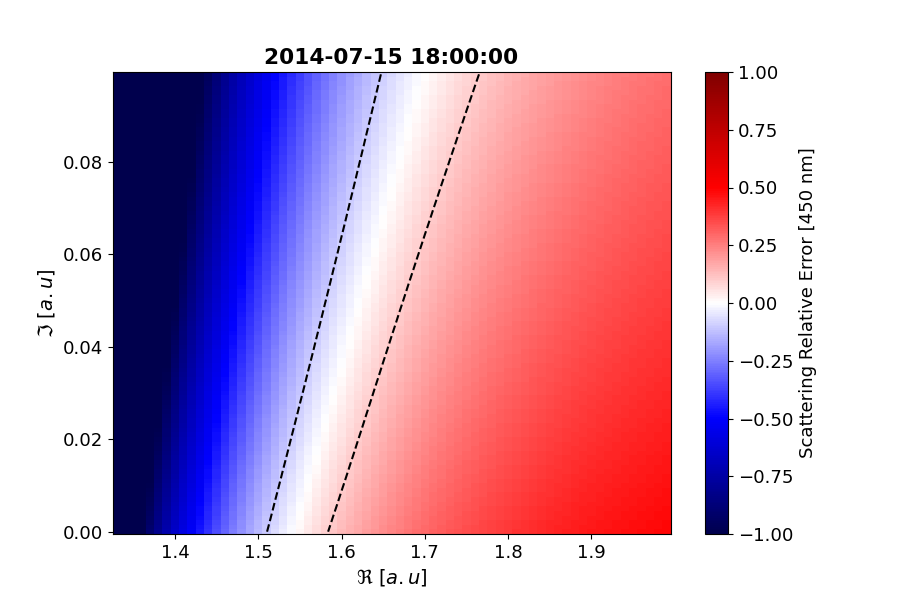

/tmp/ipykernel_291287/1220380541.py:34: RuntimeWarning: divide by zero encountered in true_divide
  f_abs637 = 1-measured_2014071518[1]/abs_637[4]


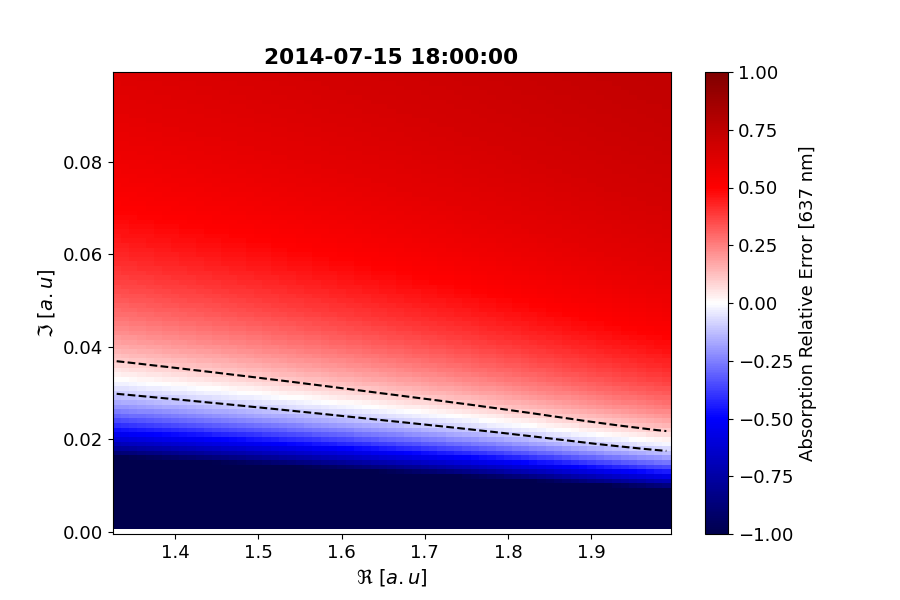

In [32]:
                                # Scat 450 nm     Abs 637   
measured_2014071518 = np.array([25.0400000000000, 2.15516400000000])

scat_450 = dic_mie_output['20140715180000_SIZEDIST_refrac_index_450.0_mie.cdf']
f_scat450 = 1-measured_2014071518[0]/scat_450[3]

fig = plt.figure(figsize=[9, 6])
ax1 = plt.subplot()
colormesh = plt.pcolormesh(scat_450[0],scat_450[1], f_scat450,
                          cmap='seismic',
                          vmin=-1,
                          vmax=1)
contour = plt.contour(scat_450[0],scat_450[1], f_scat450, colors='black', linestyles='dashed', levels = [-.1, .1,])

ttl = ax1.set_title(str(time_serie[1]))
ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_style('italic')
xlabx.set_size(14)
xlaby.set_style('italic')
xlaby.set_size(14)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'$\Im\ [a.u]$')
ax1.set_xlabel(r'$\Re\ [a.u]$')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Scattering Relative Error [450 nm]')
plt.savefig(PATH_FIG+"scat450nm_convergencemap_20140715180000_SIZEDIST.png", dpi=400)
plt.show()

abs_637 = dic_mie_output['20140715180000_SIZEDIST_refrac_index_637.0_mie.cdf']
f_abs637 = 1-measured_2014071518[1]/abs_637[4]

fig = plt.figure(figsize=[9, 6])
ax1 = plt.subplot()

colormesh = plt.pcolormesh(abs_637[0],abs_637[1], f_abs637,
                          cmap='seismic',
                          vmin=-1,
                          vmax=1)
contour = plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])

ttl = ax1.set_title(str(time_serie[1]))
ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_style('italic')
xlabx.set_size(14)
xlaby.set_style('italic')
xlaby.set_size(14)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'$\Im\ [a.u]$')
ax1.set_xlabel(r'$\Re\ [a.u]$')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Absorption Relative Error [637 nm]')
plt.savefig(PATH_FIG+"abs637nm_convergencemap_20140715180000_SIZEDIST.png", dpi=400)
plt.show()

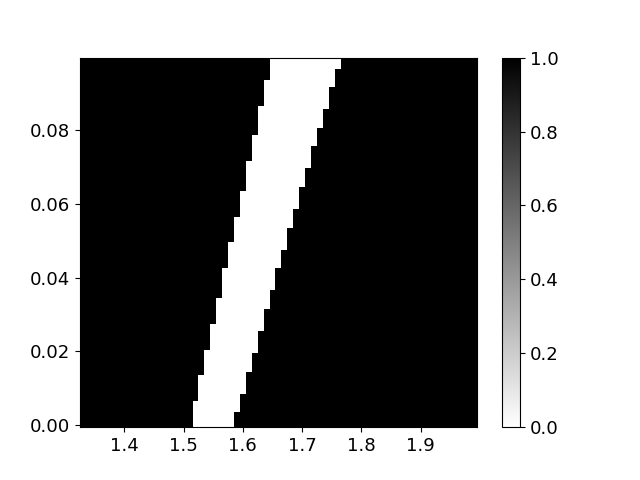

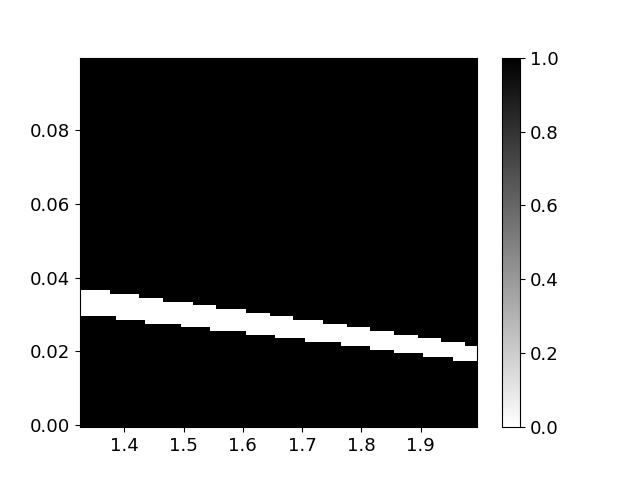

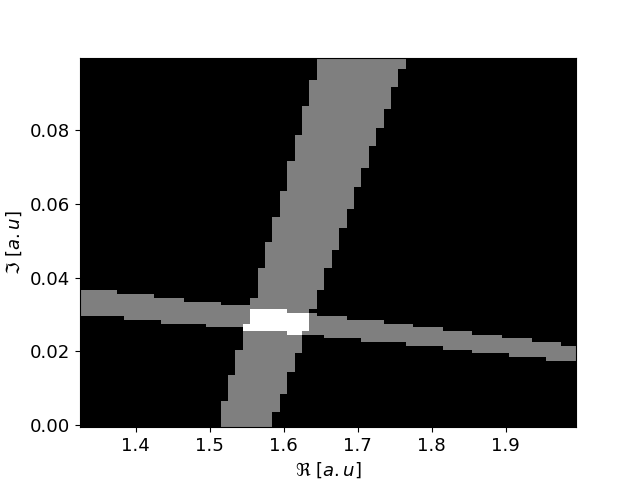

1.6100000143051147 0.02500000037252903
1.6200000047683716 0.02500000037252903
1.5499999523162842 0.026000000536441803
1.559999942779541 0.026000000536441803
1.5700000524520874 0.026000000536441803
1.5800000429153442 0.026000000536441803
1.590000033378601 0.026000000536441803
1.600000023841858 0.026000000536441803
1.6100000143051147 0.026000000536441803
1.6200000047683716 0.026000000536441803
1.6299999952316284 0.026000000536441803
1.5499999523162842 0.027000000700354576
1.559999942779541 0.027000000700354576
1.5700000524520874 0.027000000700354576
1.5800000429153442 0.027000000700354576
1.590000033378601 0.027000000700354576
1.600000023841858 0.027000000700354576
1.6100000143051147 0.027000000700354576
1.6200000047683716 0.027000000700354576
1.6299999952316284 0.027000000700354576
1.559999942779541 0.02800000086426735
1.5700000524520874 0.02800000086426735
1.5800000429153442 0.02800000086426735
1.590000033378601 0.02800000086426735
1.600000023841858 0.02800000086426735
1.61000001430511

In [33]:
plt.figure()
#Zm1 = np.ma.masked_where(np.abs(f_scat450) < 0.1, f_scat450)
Zm1 = Zm2 = np.where(np.abs(f_scat450) <= 0.1, f_scat450, 1) # Dentro do intervalo de convergência, substitui valores por 0
Zm1[Zm1<=0.1] = 0 # Fora do intervalo de convergencia, substitui valores por 1
plt.pcolormesh(scat_450[0],scat_450[1], Zm1,
                          cmap='binary')
plt.colorbar()
#plt.contour(scat_450[0],scat_450[1], f_scat450, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

#Zm2 = np.ma.masked_where(np.abs(f_abs637) < 0.1, f_abs637)
Zm2 = np.where(np.abs(f_abs637) <= 0.1, f_abs637, 1) # Fora do intervalo de convergencia, substitui valores por 2
Zm2[Zm2<=.1] = 0 # Dentro do intervalo de convergência, substitui valores por 0
plt.figure()
plt.pcolormesh(abs_637[0],abs_637[1], Zm2,cmap='binary')
plt.colorbar()
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

intersec_abs_scat = Zm2+Zm1
plt.figure()
plt.pcolormesh(abs_637[0],abs_637[1], intersec_abs_scat, cmap='binary', zorder=1)
#plt.colorbar()
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.ylabel(r'$\Im\ [a.u]$')
plt.xlabel(r'$\Re\ [a.u]$')
plt.savefig(PATH_FIG+"intersec_abs637_scat450_20140715180000_SIZEDIST.png", dpi=400)
plt.show()

index = np.where(intersec_abs_scat == 0)
aux_re = np.zeros(index[0].shape[0])
aux_im = np.zeros(index[0].shape[0])
for i in range(index[0].shape[0]):
    xi = index[0][i]
    yi = index[1][i]
    #print(xiscatter
    print(abs_637[0][xi, yi], abs_637[1][xi, yi])
    #aux_re[i] = abs_637[0][xi, yi]
    #aux_im[i] = abs_637[1][xi, yi]
    

#plt.figure()
#plt.scatter(aux_re, aux_im, c='r',s=20, marker='s')
#plt.show()

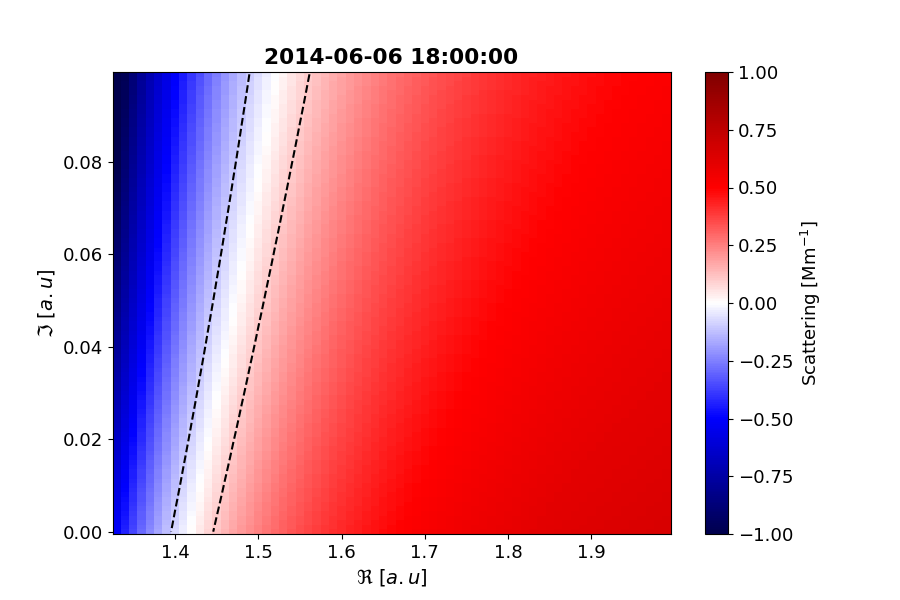

/tmp/ipykernel_291287/2308258719.py:33: RuntimeWarning: divide by zero encountered in true_divide
  f_abs637 = 1-measured_2014060618[1]/abs_637[4]


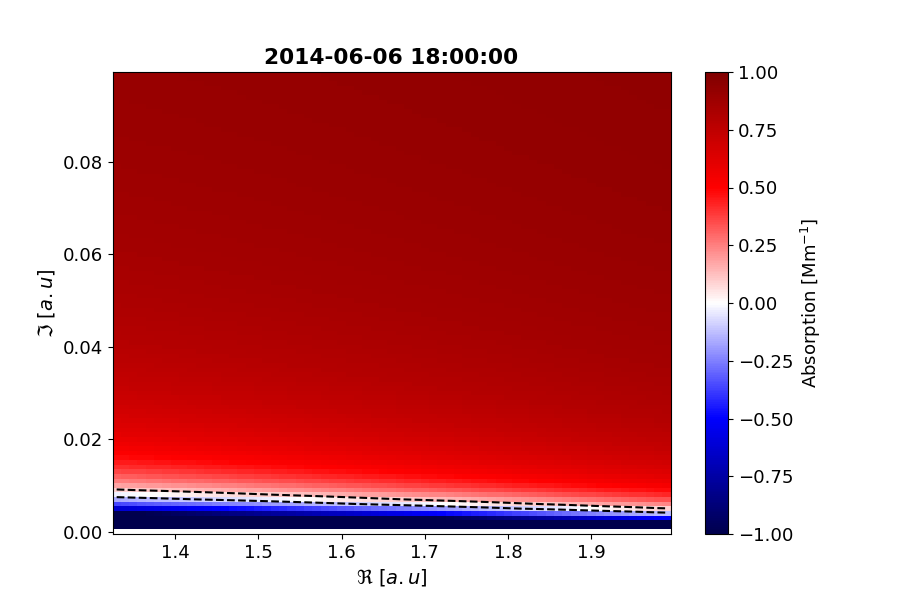

In [34]:
                                   # Scat 450 nm      Abs 637   
measured_2014060618 = np.array([17.5500000000000, 0.580470000000000])
scat_450 = dic_mie_output['20140606180000_SIZEDIST_refrac_index_450.0_mie.cdf']
f_scat450 = 1-measured_2014060618[0]/scat_450[3]

fig = plt.figure(figsize=[9, 6])
ax1 = plt.subplot()
colormesh = plt.pcolormesh(scat_450[0],scat_450[1], f_scat450,
                          cmap='seismic',
                          vmin=-1,
                          vmax=1)
contour = plt.contour(scat_450[0],scat_450[1], f_scat450, colors='black', linestyles='dashed', levels = [-.1, .1,])

ttl = ax1.set_title(str(time_serie[0]))
ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_style('italic')
xlabx.set_size(14)
xlaby.set_style('italic')
xlaby.set_size(14)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'$\Im\ [a.u]$')
ax1.set_xlabel(r'$\Re\ [a.u]$')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Scattering [Mm$^{-1}]$')
plt.savefig(PATH_FIG+"scat450nm_convergencemap_20140606180000_SIZEDIST.png", dpi=400)
plt.show()

abs_637 = dic_mie_output['20140606180000_SIZEDIST_refrac_index_637.0_mie.cdf']
f_abs637 = 1-measured_2014060618[1]/abs_637[4]

fig = plt.figure(figsize=[9, 6])
ax1 = plt.subplot()
colormesh = plt.pcolormesh(abs_637[0],abs_637[1], f_abs637,
                          cmap='seismic',
                          vmin=-1,
                          vmax=1)
contour = plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])    
ttl = ax1.set_title(str(time_serie[0]))
ttl.set_weight('bold')


xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_style('italic')
xlabx.set_size(14)
xlaby.set_style('italic')
xlaby.set_size(14)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'$\Im\ [a.u]$')
ax1.set_xlabel(r'$\Re\ [a.u]$')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Absorption [Mm$^{-1}]$')
plt.savefig(PATH_FIG+"abs637nm_convergencemap_20140606180000_SIZEDIST.png", dpi=400)
plt.show()

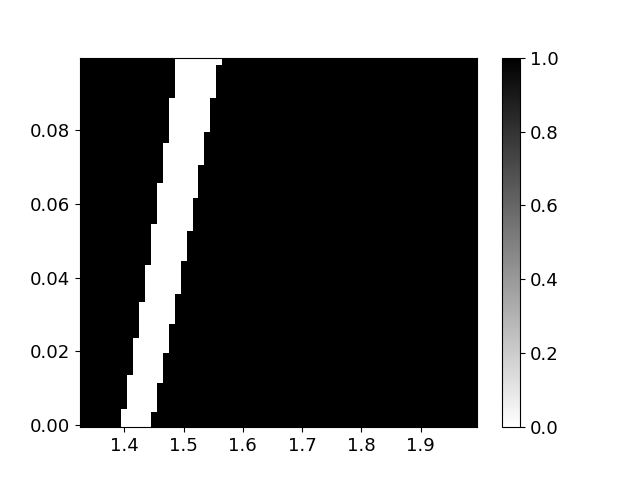

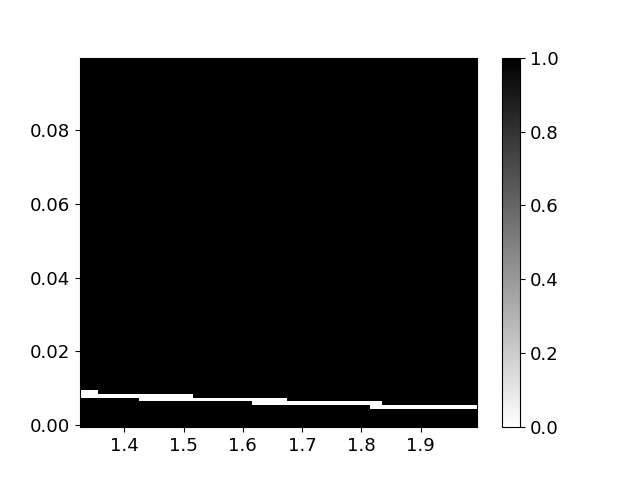

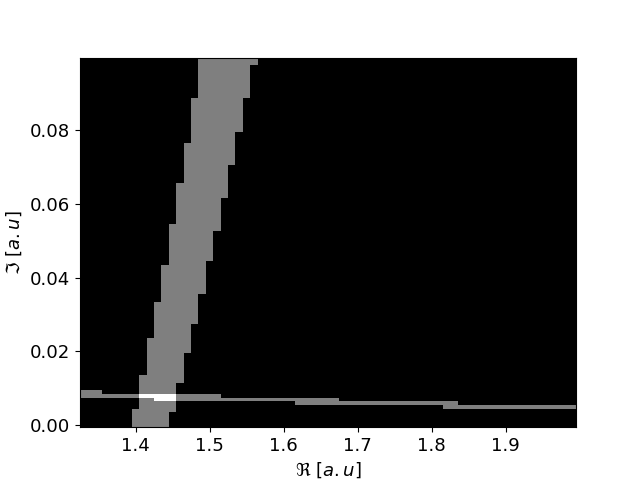

1.4299999475479126 0.007000000216066837
1.440000057220459 0.007000000216066837
1.4500000476837158 0.007000000216066837
1.409999966621399 0.00800000037997961
1.4199999570846558 0.00800000037997961
1.4299999475479126 0.00800000037997961
1.440000057220459 0.00800000037997961
1.4500000476837158 0.00800000037997961


In [35]:
plt.figure()
#Zm1 = np.ma.masked_where(np.abs(f_scat450) < 0.1, f_scat450)
Zm1 = Zm2 = np.where(np.abs(f_scat450) <= 0.1, f_scat450, 1) # Dentro do intervalo de convergência, substitui valores por 0
Zm1[Zm1<=0.1] = 0 # Fora do intervalo de convergencia, substitui valores por 1
plt.pcolormesh(scat_450[0],scat_450[1], Zm1,
                          cmap='binary')
plt.colorbar()
#plt.contour(scat_450[0],scat_450[1], f_scat450, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

#Zm2 = np.ma.masked_where(np.abs(f_abs637) < 0.1, f_abs637)
Zm2 = np.where(np.abs(f_abs637) <= 0.1, f_abs637, 1) # Fora do intervalo de convergencia, substitui valores por 2
Zm2[Zm2<=.1] = 0 # Dentro do intervalo de convergência, substitui valores por 0
plt.figure()
plt.pcolormesh(abs_637[0],abs_637[1], Zm2,cmap='binary')
plt.colorbar()
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

c = Zm2+Zm1
plt.figure()
plt.pcolormesh(abs_637[0],abs_637[1], c,cmap='binary')
#plt.colorbar()
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.ylabel(r'$\Im\ [a.u]$')
plt.xlabel(r'$\Re\ [a.u]$')
plt.savefig(PATH_FIG+"intersec_abs637_scat450_20140606180000_SIZEDIST.png", dpi=400)
plt.show()

index = np.where(c == 0)
for i in range(index[0].shape[0]):
    xi = index[0][i]
    yi = index[1][i]
    #print(xi, yi)
    print(abs_637[0][xi, yi], abs_637[1][xi, yi])


# Testing The Convergence Algorithm For All Combinations (in fact, 4) of Max and Min Values of Real and Imaginary parts 
## The Size Distribution Was Set to SMPS data at 2014-7-15 at 18 hours (LT)

### Suggestion of Imporvements
- Write a line code for verificating the convergence. Is there cases of non-solution?

In [12]:
interv_re = [1.33, 2.0]
interv_im = [0.0, 0.1]
# Aviso:
# Criar Pool para os indices de refração 
results = {}
for ire in interv_re:
    for iim in interv_im:
        results[(ire, iim)] = abs_scat_converges(measured_2014071518[0],
                           measured_2014071518[1],
                           ire,
                           iim,
                           0.01,
                           0.001,
                           0.05,
                           PATH_SIZDIST,
                           '20140715180000_SIZEDIST.DAT',
                           '../mie_out_2/',
                           [450., 637.])

/tmp/ipykernel_291287/3919579052.py:83: RuntimeWarning: divide by zero encountered in double_scalars
  fabs = abs_m/qabs[1][0]


Re = 1.33000 Im = 0.0000 qabs_err = -inf qscat_err = -1.36 Abs = 0.00, Scat = 10.63
Re = 1.33000 Im = 0.0010 qabs_err = -30.226 qscat_err = -1.37 Abs = 0.07, Scat = 10.58
Re = 1.33000 Im = 0.0020 qabs_err = -14.641 qscat_err = -1.38 Abs = 0.14, Scat = 10.53
Re = 1.33000 Im = 0.0030 qabs_err = -9.446 qscat_err = -1.39 Abs = 0.21, Scat = 10.49
Re = 1.33000 Im = 0.0040 qabs_err = -6.849 qscat_err = -1.40 Abs = 0.27, Scat = 10.44
Re = 1.33000 Im = 0.0050 qabs_err = -5.290 qscat_err = -1.41 Abs = 0.34, Scat = 10.40
Re = 1.33000 Im = 0.0060 qabs_err = -4.251 qscat_err = -1.42 Abs = 0.41, Scat = 10.35
Re = 1.33000 Im = 0.0070 qabs_err = -3.509 qscat_err = -1.43 Abs = 0.48, Scat = 10.31
Re = 1.33000 Im = 0.0080 qabs_err = -2.952 qscat_err = -1.44 Abs = 0.55, Scat = 10.27
Re = 1.33000 Im = 0.0090 qabs_err = -2.519 qscat_err = -1.45 Abs = 0.61, Scat = 10.22
Re = 1.33000 Im = 0.0100 qabs_err = -2.173 qscat_err = -1.46 Abs = 0.68, Scat = 10.18
Re = 1.33000 Im = 0.0110 qabs_err = -1.890 qscat_err =

# Map of Possible Solutions of Real and Imaginary Parts in combination with a scatter plot showing 4 solutions provided by the convergence algorithm


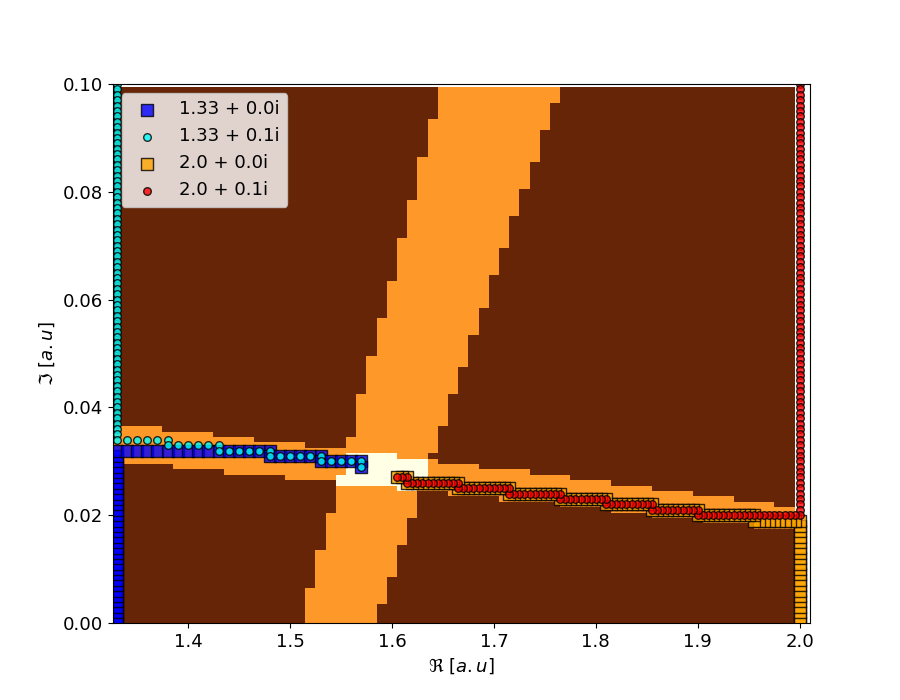

In [14]:
plt.figure(figsize=[9, 7])
plt.pcolormesh(refrac_real, refrac_im, intersec_abs_scat, cmap='YlOrBr', zorder=1)
#plt.colorbar()
plt.scatter(results[1.33, 0.0][:,0], results[1.33, 0.0][:,1], s=80, c='blue',zorder=2, marker='s', edgecolors='black', alpha=.8,
           label='1.33 + 0.0i')
plt.scatter(results[1.33, 0.1][:,0], results[1.33, 0.1][:,1], s=30, c='cyan',zorder=2, marker='o', edgecolors='black', alpha=.8,
           label='1.33 + 0.1i')
plt.scatter(results[2.0, 0.0][:,0], results[2.0, 0.0][:,1], s=80, c='orange',zorder=2, marker='s', edgecolors='black', alpha=.8,
           label='2.0 + 0.0i')
plt.scatter(results[2.0, 0.1][:,0], results[2.0, 0.1][:,1], s=30, c='red',zorder=2, marker='o', edgecolors='black', alpha=.8,
           label='2.0 + 0.1i')
plt.legend()
plt.xlim([1.326, 2.01])
plt.ylim([0.0, 0.1])
plt.ylabel(r'$\Im\ [a.u]$')
plt.xlabel(r'$\Re\ [a.u]$')
plt.savefig(PATH_FIG+"intersec_map_plus_4_output_convergent_paths.png", dpi=400)
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

/tmp/ipykernel_3743179/2960022426.py:14: RuntimeWarning: divide by zero encountered in true_divide
  fabs = 1-measured_2014071518[1]/results[key][:,3]


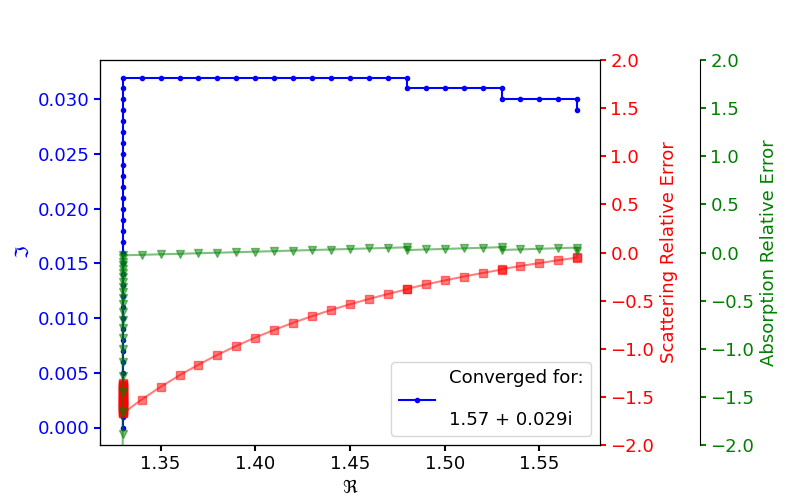

/tmp/ipykernel_3743179/2960022426.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots()


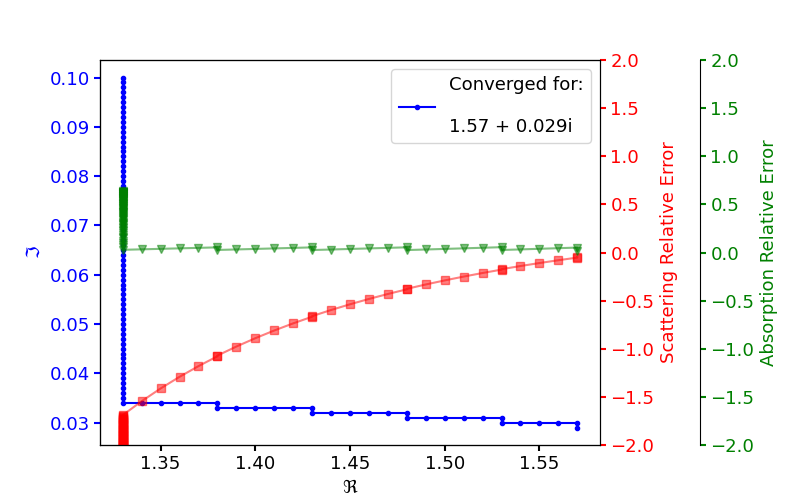

/tmp/ipykernel_3743179/2960022426.py:14: RuntimeWarning: divide by zero encountered in true_divide
  fabs = 1-measured_2014071518[1]/results[key][:,3]


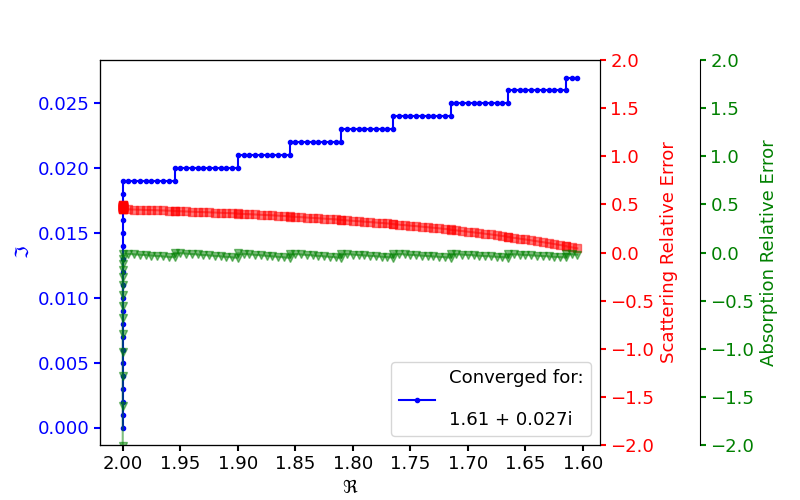

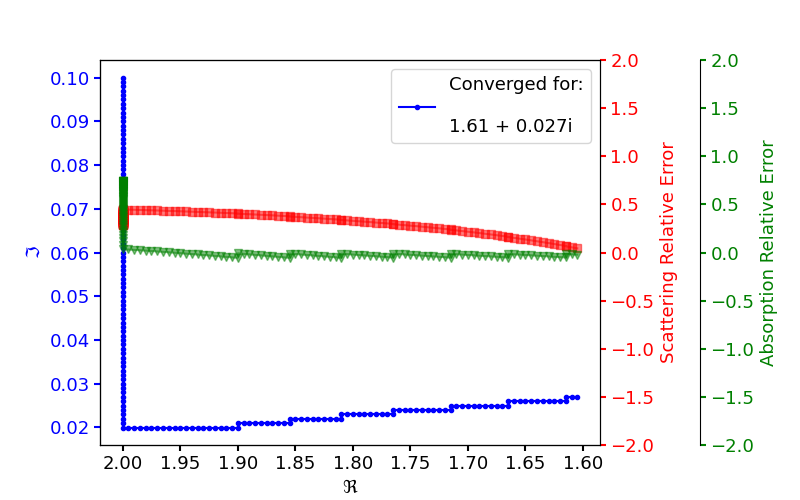

In [46]:

for key in results:
    fig, ax = plt.subplots()
    fig.subplots_adjust(right=0.75)
    fig.set_size_inches(8, 5)

    twin1 = ax.twinx()
    twin2 = ax.twinx()

    # Offset the right spine of twin2.  The ticks and label have already been
    # placed on the right by twinx above.
    twin2.spines.right.set_position(("axes", 1.2))

    fscat = 1-measured_2014071518[0]/results[key][:,2]
    fabs = 1-measured_2014071518[1]/results[key][:,3]
    #fscat = results[key][:,2]
    #fabs = results[key][:,3]
    p1, = ax.plot(results[key][:,0], results[key][:,1], "b-", marker='.',
                  label="Converged for:\n\n%.2f + %.3fi"%(results[key][-1,0], results[key][-1,1]))
    p2, = twin1.plot(results[key][:,0], fscat,
                 "r-",
                 marker='s',
                 alpha=.5)
    p3, = twin2.plot(results[key][:,0], fabs, 
                 "g-",
                 marker='v',
                alpha=.5)

    #ax.set_xlim(min(results[1.33, 0.0][:,0])-.01, max(results[1.33, 0.0][:,0]))
    #ax.set_ylim(min(results[1.33, 0.0][:,1])+.05, max(results[1.33, 0.0][:,1]))
    twin1.set_ylim(-2, 2)
    twin2.set_ylim(-2, 2)

    ax.set_xlabel(r"$\Re$ [a.u]")
    ax.set_ylabel(r"$\Im$ [a.u]")
    twin1.set_ylabel("Scattering Relative Error [450 nm]")
    twin2.set_ylabel("Absorption Relative Error [637 nm]")
    
    if key[0] == 2.0:
        ax.invert_xaxis()


    ax.yaxis.label.set_color(p1.get_color())
    twin1.yaxis.label.set_color(p2.get_color())
    twin2.yaxis.label.set_color(p3.get_color())

    tkw = dict(size=4, width=1.5)
    ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
    twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
    twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
    ax.tick_params(axis='x', **tkw)
    #ax.legend(handles=[p1, p2, p3])
    ax.legend(handles=[p1])
    plt.savefig(PATH_FIG+"4_output_convergent_paths_ini"+"{:.2f}".format(key[0])+"_"+"{:.3f}".format(key[1])+".png", dpi=400)
    plt.show()

In [19]:
interv_re = [1.33, 2.0]
interv_im = [0.0, 0.1]
# Aviso:
# Criar Pool para os indices de refração 
results = {}
for ire in interv_re:
    for iim in interv_im:
        results[(ire, iim)] = abs_scat_converges(measured_2014060618[0],
                           measured_2014060618[1],
                           ire,
                           iim,
                           0.01,
                           0.0005,
                           0.1,
                           PATH_SIZDIST,
                           '20140606180000_SIZEDIST.DAT',
                           '../mie_out_2/',
                           [450., 637.])

/tmp/ipykernel_3963643/3919579052.py:83: RuntimeWarning: divide by zero encountered in double_scalars
  fabs = abs_m/qabs[1][0]


Re = 1.33000 Im = 0.0000 qabs_err = -inf qscat_err = -0.52 Abs = 0.00, Scat = 11.58
Re = 1.33000 Im = 0.0005 qabs_err = -15.152 qscat_err = -0.52 Abs = 0.04, Scat = 11.55
Re = 1.33000 Im = 0.0010 qabs_err = -7.084 qscat_err = -0.52 Abs = 0.07, Scat = 11.52
Re = 1.33000 Im = 0.0015 qabs_err = -4.395 qscat_err = -0.53 Abs = 0.11, Scat = 11.49
Re = 1.33000 Im = 0.0020 qabs_err = -3.050 qscat_err = -0.53 Abs = 0.14, Scat = 11.47
Re = 1.33000 Im = 0.0025 qabs_err = -2.243 qscat_err = -0.53 Abs = 0.18, Scat = 11.44
Re = 1.33000 Im = 0.0030 qabs_err = -1.705 qscat_err = -0.54 Abs = 0.21, Scat = 11.41
Re = 1.33000 Im = 0.0035 qabs_err = -1.321 qscat_err = -0.54 Abs = 0.25, Scat = 11.39
Re = 1.33000 Im = 0.0040 qabs_err = -1.033 qscat_err = -0.54 Abs = 0.29, Scat = 11.36
Re = 1.33000 Im = 0.0045 qabs_err = -0.809 qscat_err = -0.55 Abs = 0.32, Scat = 11.34
Re = 1.33000 Im = 0.0050 qabs_err = -0.630 qscat_err = -0.55 Abs = 0.36, Scat = 11.31
Re = 1.33000 Im = 0.0055 qabs_err = -0.483 qscat_err = 

In [ ]:
plt.figure(figsize=[9, 6])
plt.pcolormesh(refrac_real, refrac_im, intersec_abs_scat, cmap='YlOrBr', zorder=1)
plt.colorbar()
plt.scatter(results[1.33, 0.0][:,0], results[1.33, 0.0][:,1], s=80, c='blue',zorder=2, marker='s', edgecolors='black', alpha=.8,
           label='1.33 + 0.0i')
plt.scatter(results[1.33, 0.1][:,0], results[1.33, 0.1][:,1], s=30, c='cyan',zorder=2, marker='o', edgecolors='black', alpha=.8,
           label='1.33 + 0.1i')
plt.scatter(results[2.0, 0.0][:,0], results[2.0, 0.0][:,1], s=80, c='orange',zorder=2, marker='s', edgecolors='black', alpha=.8,
           label='2.0 + 0.0i')
plt.scatter(results[2.0, 0.1][:,0], results[2.0, 0.1][:,1], s=30, c='red',zorder=2, marker='o', edgecolors='black', alpha=.8,
           label='2.0 + 0.1i')
plt.legend()
plt.xlim([1.326, 2.01])
plt.ylim([0.0, 0.1])
plt.savefig(PATH_FIG+"intersec_map_plus_4_output_convergent_paths.png", dpi=400)
#plt.contour(abs_637[0],abs_637[1], f_abs637, colors='black', linestyles='dashed', levels = [-.1, .1,])
plt.show()

In [ ]:
for key in results:
    fig, ax = plt.subplots()
    fig.subplots_adjust(right=0.75)
    fig.set_size_inches(8, 5)

    twin1 = ax.twinx()
    twin2 = ax.twinx()

    # Offset the right spine of twin2.  The ticks and label have already been
    # placed on the right by twinx above.
    twin2.spines.right.set_position(("axes", 1.2))

    fscat = 1-measured_2014071518[0]/results[key][:,2]
    fabs = 1-measured_2014071518[1]/results[key][:,3]
    #fscat = results[key][:,2]
    #fabs = results[key][:,3]
    p1, = ax.plot(results[key][:,0], results[key][:,1], "b-", marker='.',
                  label="Converged for:\n\n%.2f + %.3fi"%(results[key][-1,0], results[key][-1,1]))
    p2, = twin1.plot(results[key][:,0], fscat,
                 "r-",
                 marker='s',
                 alpha=.5)
    p3, = twin2.plot(results[key][:,0], fabs, 
                 "g-",
                 marker='v',
                alpha=.5)

    #ax.set_xlim(min(results[1.33, 0.0][:,0])-.01, max(results[1.33, 0.0][:,0]))
    #ax.set_ylim(min(results[1.33, 0.0][:,1])+.05, max(results[1.33, 0.0][:,1]))
    twin1.set_ylim(-2, 2)
    twin2.set_ylim(-2, 2)

    ax.set_xlabel(r"$\Re$")
    ax.set_ylabel(r"$\Im$")
    twin1.set_ylabel("Scattering Relative Error")
    twin2.set_ylabel("Absorption Relative Error")
    
    if key[0] == 2.0:
        ax.invert_xaxis()


    ax.yaxis.label.set_color(p1.get_color())
    twin1.yaxis.label.set_color(p2.get_color())
    twin2.yaxis.label.set_color(p3.get_color())

    tkw = dict(size=4, width=1.5)
    ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
    twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
    twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
    ax.tick_params(axis='x', **tkw)
    #ax.legend(handles=[p1, p2, p3])
    ax.legend(handles=[p1])
    plt.savefig(PATH_FIG+"4_output_convergent_paths_ini"+"{:.2f}".format(key[0])+"_"+"{:.3f}".format(key[1])+".png", dpi=400)
    plt.show()

In [ ]:
fig = plt.figure(figsize=(6, 6))
cm = plt.cm.get_cmap('cool')
plt.scatter(dic_output[szdist][:,0], dic_output[szdist][:,1],
           linewidths=1, alpha=.7,
           edgecolor='k',
           s = 200,
           c=abs(1-measured_2014071518[0]/dic_output[szdist][:,2])*100,
           vmin=0, vmax=100,
           cmap=cm)
plt.grid()
cbar = plt.colorbar()
cbar.set_label(r'Relative Scattering Error')
plt.show()

fig = plt.figure(figsize=(6, 6))
cm = plt.cm.get_cmap('cool')
plt.scatter(dic_output[szdist][:,0], dic_output[szdist][:,1],
           linewidths=1, alpha=.7,
           edgecolor='k',
           s = 200,
           c=abs(1-measured_2014071518[1]/dic_output[szdist][:,3])*100,
           vmin=0, vmax=100,
           cmap=cm)

#plt.yscale('log')
plt.grid()
cbar = plt.colorbar()
cbar.set_label(r'Relative Absorption Error')
plt.show()

# Convergence Algorithm For One Pair of Refractive Index and One Size Distribution 
## Test, Changes and Analysis will be done here first

In [24]:
                                   # Scat 450 nm      Abs 637   
measured_2014071518 = np.array([25.0400000000000, 2.15516400000000])
PATH_OUT_MIE_2 = '../mie_out_2/'

# reading refracive index filenames for each wavelengh:
dir_list_sizdist = os.listdir(PATH_SIZDIST)
# criate mie input files and save the input filename for each wavelengh:
mie_inputs_2 = []
mie_outputs_2 = []
input_filenames_2 = []
verb_filename_2 = []
outp_filename_2 = []
dic_output = {}
rho = 1 # g/cm^3
szdist = '20140715180000_SIZEDIST.DAT'
# First step:
# We should find Re and Im that matches the computed absorption coefficient with the measurement
# We start with Re = min(Re) and Im = min(Im)
# Then we increase the imaginary part untill (abs.coef_sim - abs.coef_meas) < +-epsilon
# where epsilin is the relative error
#ref: P. Guyon et al. / Aerosol Science 34 (2003) 883 – 907
delta = 0.001
error_qscat = 0
error_qabs = 10
epsilon_qscat = 0.05
epsilon_qabs = 0.05
results = []
i_f = 0
#real_min, real_max = 1.33, 2.0
#im_min, im_max = 0.0, 0.3
#re = real_min
#im  = im_min
re = 1.33
im  = 0.0
while abs(error_qabs) > epsilon_qabs or abs(error_qscat) > epsilon_qscat:
    # criating the dictionary that will be used to write the input file:
    input_filenames_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'.inp')
    verb_filename_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_verb.txt')
    outp_filename_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_')
    mie_inputs_2.append({'mie_program': 'MIEV0',
                             'refrac user': str(re) + ' ' + str(im),  
                             'size_distribution_file':PATH_SIZDIST+szdist,
                             'wavelength': '450 637',
                             'wavelength_step':187,  
                             'nstokes':4,
                             'nmom':2000,
                             'dx_max':0.0003 ,
                             'n_r_max':20 ,
                             'output_user':'netcdf',
                             'basename':PATH_OUT_MIE_2+outp_filename_2[i_f], 
                             'verbose':''})

    # run the mie code:
    run_mie_sizedist(mie_inputs_2[i_f],
                         './mie_inputs_2/'+input_filenames_2[i_f],
                         './mie_inputs_2/'+verb_filename_2[i_f])

        # read mie output:
    ree = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['refre'][:]
    imm = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['refim'][:]
    ext = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['ext'][:] # km^-1/(g/m^3)
    ssa = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['ssa'][:]
    sizdist = np.loadtxt(PATH_SIZDIST+szdist) # 2 column: (micro m)^-1 cm^-3
    n_m = (rho/1e6)*4/3*np.pi*sizdist[:,0]**3*sizdist[:,1] # mircro g/(micro m^3) x (micro m)^2 cm^-3 
                                                                    # = mircro g micro m^-1 cm^-3 
    mass = integrate.simps(n_m, sizdist[:,0]) # mircro g cm^-3 == g/m^3
    qext = ext*1e3*mass
    qscat = ssa*qext
    qabs = (1-ssa)*qext
    results.append([ree[0], imm[0], qscat[0][0], qabs[1][0], mass])
    #error_qabs = abs(measured_2014071518[1] - qabs[1][0])
    #error_qscat = abs(measured_2014071518[0] - qscat[0][0])
    #error_qabs = measured_2014071518[1] - qabs[1][0]
    #error_qscat = measured_2014071518[0] - qscat[0][0]
    
    fabs = measured_2014071518[1]/qabs[1][0]
    fscat = measured_2014071518[0]/qscat[0][0]
    error_qabs = 1-fabs
    error_qscat = 1-fscat
    # If Scat_measured >= Scat_calc --> fscat >= 1
    #             Otherwise    ------> fscat < 1
    
    # (1) condição em que Abs medido >= Abs calculado
    # (2)o erro em Abs > 5 %
    # Se fabs >= 1 -> (1) Abs_m >= Abs_c
    # -> 1-fabs <= 0 # (<=0) Abs_m >= Abs_c
    # -> 1-fabs < -0.05 # Aqui, Abs_m >= Abs_c e erro Abs > - 5%
    ##### Aumenta Im #####
    
    # Saiu porque:
    # 1-fabs > 0 (Abs_m < Abs_c) (1*)
    # ou Erro Abs <= -5% (2*) --------------------- Talvez deixar pro primeiro loop
    
    # Se erro na absorção foi satisfeito, vamos mexer no espalhamento (ou seja, em Re)
    # Portanto, devemos verificar se:
    # (3) Erro Abs <= 5% (Verifica (2*))
    # (4) Scat_m >= Scat_c
    # (5) Erro Scat > 5% 
    #
    # Se 1-fabs <= 0 (Verifica (3 ou 2*) - Eu sei que saiu do loop acima por conta do erro ser menor que 5%)
    # Se fscat >= 1 Scat_m >= Scat_c
    # 1-fscat <= 0
    # 1-fscat <= -0.05, Verifica(4 e 5) Aqui, Scat_m >= Scat_c e erro Scat > -5%
    ##### Aumenta Re #####
    
    # Saiu porque:
    # 1-fabs > 0 (Abs_m < Abs_c) (1*)
    # 1-fscat > 0 (Scat_m < Scat_c) (4*)
    # Erro Scat <= -5% (5*)
    
    # se erro no espalhamento não foi satisfeito, e ele é maior que o medido
    # devemos diminuir o Re
    # se 1-fscat <= 0 eu sei que saiu do loop acima por conta o erro do espalhamento foi satisfeito, ou por Abs_m < Abs_c:
    # portanto, devemos verificar:
    # Se fscat < 1 
    # -> 1-fscat > 0  # (Scat_m < Scat_c) Verifica (4*)
    # -> 1-fscat > 0.05 # Verifica 4*, ou seja: Scat_m < Scat_c e também Erro Scat > 5%
    # -> 1-fscat <= 0 # Verifica (5*) - Scat_m >= Sca_c, porém, o erro é menor que -5%
    ##### Diminui Re
    
    # Saiu por que:
    # 1-fabs > 0 (Abs_m < Abs_c) (1*)
    # verificar se o erro na absrorção 
    ##### Diminui Im #####
    print("Re = %.5f Im = %.4f qabs_err = %.3f qscat_err = %.2f Abs = %.2f, Scat = %.2f"%(re, im, error_qabs, error_qscat, qabs[1][0], qscat[0][0]))
    #print(error_qabs, error_qscat, qscat[0][0], qabs[1][0])
    i_f+=1
    if error_qabs < -epsilon_qabs:
        # entra se absorção calculada <= medida
        # e se erro na absorção > -5%
        # --> devemos aumentar Im
        im += delta
    elif error_qabs > epsilon_qabs:
        im -= delta
    
    elif error_qscat < -epsilon_qscat:
        # absorção calculada > medida 
        # erro absorção < 5 %
        # Portanto, erro espalhamento > -5%
        # espalhemnto calculada <= medido
        # --> devemos aumentar Re
        re += 0.01
    else:
        # espalhemnto calculada > medido
        # erro no  espalhamento > +5%
        # absorção calculada > medida 
        # erro absorção > 5 %
        re -= 0.01/2
        
    # OBS: Camiho física que faz sentido
    
    #if error_qabs <= epsilon_qabs:
    #    print("Imaginary part converged")
    #    re += 0.01
    #elif re > real_min:
    #    im -= delta
    #else:
    #    im += delta

os.system('rm ./mie_inputs_2/*')
dic_output[szdist] = np.array(results, float)

/tmp/ipykernel_2622289/1021166747.py:76: RuntimeWarning: divide by zero encountered in double_scalars
  fabs = measured_2014071518[1]/qabs[1][0]


Re = 1.33000 Im = 0.0000 qabs_err = -inf qscat_err = -1.36 Abs = 0.00, Scat = 10.63
Re = 1.33000 Im = 0.0010 qabs_err = -30.226 qscat_err = -1.37 Abs = 0.07, Scat = 10.58
Re = 1.33000 Im = 0.0020 qabs_err = -14.641 qscat_err = -1.38 Abs = 0.14, Scat = 10.53
Re = 1.33000 Im = 0.0030 qabs_err = -9.446 qscat_err = -1.39 Abs = 0.21, Scat = 10.49
Re = 1.33000 Im = 0.0040 qabs_err = -6.849 qscat_err = -1.40 Abs = 0.27, Scat = 10.44
Re = 1.33000 Im = 0.0050 qabs_err = -5.290 qscat_err = -1.41 Abs = 0.34, Scat = 10.40
Re = 1.33000 Im = 0.0060 qabs_err = -4.251 qscat_err = -1.42 Abs = 0.41, Scat = 10.35
Re = 1.33000 Im = 0.0070 qabs_err = -3.509 qscat_err = -1.43 Abs = 0.48, Scat = 10.31
Re = 1.33000 Im = 0.0080 qabs_err = -2.952 qscat_err = -1.44 Abs = 0.55, Scat = 10.27
Re = 1.33000 Im = 0.0090 qabs_err = -2.519 qscat_err = -1.45 Abs = 0.61, Scat = 10.22
Re = 1.33000 Im = 0.0100 qabs_err = -2.173 qscat_err = -1.46 Abs = 0.68, Scat = 10.18
Re = 1.33000 Im = 0.0110 qabs_err = -1.890 qscat_err =

/tmp/ipykernel_2622289/1021166747.py:76: RuntimeWarning: divide by zero encountered in true_divide
  fabs = measured_2014071518[1]/qabs[1][0]
/tmp/ipykernel_2622289/1021166747.py:125: UserWarning: Warning: converting a masked element to nan.
  print("Re = %.5f Im = %.4f qabs_err = %.3f qscat_err = %.2f Abs = %.2f, Scat = %.2f"%(re, im, error_qabs, error_qscat, qabs[1][0], qscat[0][0]))


Re = 1.33000 Im = 0.0180 qabs_err = nan qscat_err = -1.54 Abs = nan, Scat = 9.86


FileNotFoundError: [Errno 2] No such file or directory: b'../mie_out_2/20140715180000_SIZEDIST_1.34_0.018_mie.cdf'

In [16]:
dic_output[szdist][-1,:2]

array([1.55999994, 0.03      ])

In [12]:
dic_output[szdist][-1,:2]

array([1.55999994, 0.03      ])

In [ ]:
#re = real_min (1.33)
#im  = im_min (0.00)
dic_output[szdist][-1,:2]

array([1.59000003, 0.029     ])

In [6]:
                                   # Scat 450 nm      Abs 637   
measured_2014071518 = np.array([25.0400000000000, 2.15516400000000])
PATH_OUT_MIE_2 = '../mie_out_2/'

# reading refracive index filenames for each wavelengh:
dir_list_sizdist = os.listdir(PATH_SIZDIST)
# criate mie input files and save the input filename for each wavelengh:
mie_inputs_2 = []
mie_outputs_2 = []
input_filenames_2 = []
verb_filename_2 = []
outp_filename_2 = []
dic_output = {}
rho = 1 # g/cm^3
szdist = '20140715180000_SIZEDIST.DAT'
# First step:
# We should find Re and Im that matches the computed absorption coefficient with the measurement
# We start with Re = min(Re) and Im = min(Im)
# Then we increase the imaginary part untill (abs.coef_sim - abs.coef_meas) < +-epsilon
# where epsilin is the relative error
#ref: P. Guyon et al. / Aerosol Science 34 (2003) 883 – 907
delta = 0.001
error_qscat = 0
error_qabs = 10
epsilon_qscat = 0.01
epsilon_qabs = 0.05
results = []
i_f = 0
#real_min, real_max = 1.33, 2.0
#im_min, im_max = 0.0, 0.3
#re = real_min
#im  = im_min
re = 2.0
im  = 0.1
while abs(error_qabs) > epsilon_qabs or abs(error_qscat) > epsilon_qscat:
    # criating the dictionary that will be used to write the input file:
    input_filenames_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'.inp')
    verb_filename_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_verb.txt')
    outp_filename_2.append(szdist[:-4]+'_'+"{:.2f}".format(re)+'_'+"{:.3f}".format(im)+'_')
    mie_inputs_2.append({'mie_program': 'MIEV0',
                             'refrac user': str(re) + ' ' + str(im),  
                             'size_distribution_file':PATH_SIZDIST+szdist,
                             'wavelength': '450 637',
                             'wavelength_step':187,  
                             'nstokes':4,
                             'nmom':2000,
                             'dx_max':0.0003 ,
                             'n_r_max':20 ,
                             'output_user':'netcdf',
                             'basename':PATH_OUT_MIE_2+outp_filename_2[i_f], 
                             'verbose':''})

    # run the mie code:
    run_mie_sizedist(mie_inputs_2[i_f],
                         './mie_inputs_2/'+input_filenames_2[i_f],
                         './mie_inputs_2/'+verb_filename_2[i_f])

        # read mie output:
    ree = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['refre'][:]
    imm = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['refim'][:]
    ext = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['ext'][:] # km^-1/(g/m^3)
    ssa = nc.Dataset(PATH_OUT_MIE_2+outp_filename_2[i_f]+'mie.cdf').variables['ssa'][:]
    sizdist = np.loadtxt(PATH_SIZDIST+szdist) # 2 column: (micro m)^-1 cm^-3
    n_m = (rho/1e6)*4/3*np.pi*sizdist[:,0]**3*sizdist[:,1] # mircro g/(micro m^3) x (micro m)^2 cm^-3 
                                                                    # = mircro g micro m^-1 cm^-3 
    mass = integrate.simps(n_m, sizdist[:,0]) # mircro g cm^-3 == g/m^3
    qext = ext*1e3*mass
    qscat = ssa*qext
    qabs = (1-ssa)*qext
    results.append([ree[0], imm[0], qscat[0][0], qabs[1][0], mass])
    #error_qabs = abs(measured_2014071518[1] - qabs[1][0])
    #error_qscat = abs(measured_2014071518[0] - qscat[0][0])
    error_qabs = measured_2014071518[1] - qabs[1][0]
    error_qscat = measured_2014071518[0] - qscat[0][0]
    print("Re = %.5f Im = %.4f qabs_err = %.3f qscat_err = %.2f Abs = %.2f"%(re, im, error_qabs, error_qscat, qabs[1][0]))
    #print(error_qabs, error_qscat, qscat[0][0], qabs[1][0])
    i_f+=1
    if error_qabs >= 0 and abs(error_qabs) > epsilon_qabs:
        # entra se absorção calculada <= medida
        # e se erro na absorção > 5%
        # --> devemos aumentar Im
        im += delta
    elif error_qscat >= 0 and abs(error_qabs) <= epsilon_qabs:
        # absorção calculada > medida 
        # erro absorção < 5 %
        # Portanto, erro espalhamento > 5%
        # espalhemnto calculada <= medido
        # --> devemos aumentar Re
        re += 0.01
    elif abs(error_qabs) <= epsilon_qabs:
        # espalhemnto calculada > medido
        # erro no  espalhamento > 5%
        # absorção calculada > medida 
        # erro absorção > 5 %
        re -= 0.01/2
    else:
        im -= delta
    
        
    # OBS: Camiho física que faz sentido
    
    #if error_qabs <= epsilon_qabs:
    #    print("Imaginary part converged")
    #    re += 0.01
    #elif re > real_min:
    #    im -= delta
    #else:
    #    im += delta

os.system('rm ./mie_inputs_2/*')
dic_output[szdist] = np.array(results, float)

Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00


/work/alunos/matheustolen/matheustolen_doutorado/scripts/ipykernel_2510548/4169402824.py:75: UserWarning: Warning: converting a masked element to nan.
  print("Re = %.5f Im = %.4f qabs_err = %.3f qscat_err = %.2f Abs = %.2f"%(re, im, error_qabs, error_qscat, qabs[1][0]))


Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qabs_err = nan qscat_err = 14.46 Abs = nan
Re = 1.33000 Im = 0.0000 qabs_err = 2.155 qscat_err = 14.41 Abs = 0.00
Re = 1.33000 Im = 0.0010 qa

KeyboardInterrupt: 

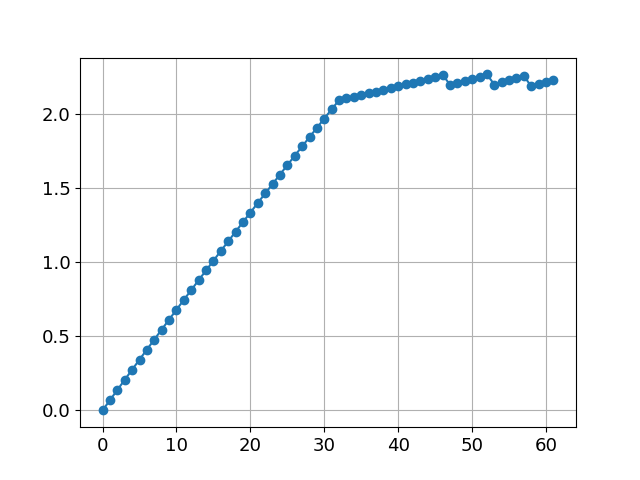

In [55]:
plt.figure()
plt.plot(dic_output[szdist][:,3], marker='o')
plt.grid()
plt.show()

In [35]:
nc.Dataset('./test_mie.cdf').variables['wavelen'][:]

masked_array(data=[0.45 , 0.637],
             mask=False,
       fill_value=1e+20)

In [33]:
nc.Dataset('./test_mie.cdf').variables['ext'][:]

masked_array(
  data=[[3857.09758216],
        [1735.8368719 ]],
  mask=False,
  fill_value=1e+20)

In [ ]:
# create the input file for the mie executable:
mie_input = {'mie_program': 'MIEV0',
               'refrac user': str(real_min) + ' ' + str(im_min), 
               'size_distribution_file':PATH_SIZDIST+'20140606180000_SIZEDIST.DAT', 
               'wavelength': '400 500',
               'wavelength_step':50, 
               'nstokes':4,
               'nmom':2000,
               'dx_max':0.0003 ,
               'n_r_max':20 ,
               'output_user':'netcdf',
               'basename':'./test_', 
               'verbose':''}